In [ ]:
from google.colab import files
file=files.upload()

Saving fashion_retail_size_demand_dataset.csv to fashion_retail_size_demand_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
df=pd.read_csv('/content/fashion_retail_size_demand_dataset.csv')
print("Dataset loaded sucessfully")
print("Total number of columns and rows:",df.shape)
# print(df.shape[0])
# print(df.shape[1])

Dataset loaded sucessfully
Total number of columns and rows: (20000, 9)


In [ ]:
df.head()

,Date,Product_ID,Size,Store_ID,Season,Units_Sold,Customer_Demographics,Return_Status,Region
0,2023-01-01,P006,S,S009,Winter,30,18-24,Not Returned,East
1,2023-01-01,P009,M,S010,Winter,42,25-34,Not Returned,East
2,2023-01-01,P023,L,S013,Winter,28,35-44,Not Returned,West
3,2023-01-01,P013,XL,S011,Winter,18,55+,Not Returned,East
4,2023-01-01,P009,S,S001,Winter,23,18-24,Not Returned,North


In [ ]:
df.describe()

,Units_Sold
count,20000.000000
mean,24.670050
std,11.020574
min,0.000000
25%,17.000000
50%,23.000000
75%,31.000000
max,77.000000


In [ ]:
#checking missing values
df.isnull().sum()

,0
Date,0
Product_ID,0
Size,0
Store_ID,0
Season,0
Units_Sold,0
Customer_Demographics,200
Return_Status,100
Region,0


In [ ]:
missing_percentage = df.isnull().mean() * 100

missing_percentage.sort_values(ascending=False)

,0
Customer_Demographics,1.0
Return_Status,0.5
Date,0.0
Product_ID,0.0
Size,0.0
Season,0.0
Store_ID,0.0
Units_Sold,0.0
Region,0.0


In [ ]:
print("Duplicate rows:",df.duplicated().sum())
df=df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Duplicate rows: 0
Rows after removing duplicates: 19999


In [ ]:
print(df['Size'].unique())

['S' 'M' 'L' 'XL' 'XXL' 'XS']


In [ ]:
print(df['Product_ID'].unique())

['P006' 'P009' 'P023' 'P013' 'P011' 'P015' 'P001' 'P027' 'P030' 'P014'
 'P018' 'P017' 'P016' 'P003' 'P020' 'P024' 'P007' 'P025' 'P002' 'P029'
 'P022' 'P026' 'P005' 'P008' 'P010' 'P012' 'P004' 'P021' 'P019' 'P028']


In [ ]:
print("Negative Units Sold:", (df["Units_Sold"] < 0).sum())

Negative Units Sold: 0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

datetime64[ns]


In [ ]:
df.head()

,Date,Product_ID,Size,Store_ID,Season,Units_Sold,Customer_Demographics,Return_Status,Region,Year,Month,Month_Name
0,2023-01-01,P006,S,S009,Winter,30,18-24,Not Returned,East,2023,1,January
1,2023-01-01,P009,M,S010,Winter,42,25-34,Not Returned,East,2023,1,January
2,2023-01-01,P023,L,S013,Winter,28,35-44,Not Returned,West,2023,1,January
3,2023-01-01,P013,XL,S011,Winter,18,55+,Not Returned,East,2023,1,January
4,2023-01-01,P009,S,S001,Winter,23,18-24,Not Returned,North,2023,1,January


In [ ]:
df["Customer_Demographics"] = df["Customer_Demographics"].fillna("Unknown")

In [ ]:
df["Return_Status"] = df["Return_Status"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
Date,0
Product_ID,0
Size,0
Store_ID,0
Season,0
Units_Sold,0
Customer_Demographics,0
Return_Status,0
Region,0
Year,0


In [ ]:
total_sales = df["Units_Sold"].sum()

print("Total Units Sold:", total_sales)

Total Units Sold: 493371


In [ ]:
print("Minimum:", df["Units_Sold"].min())
print("Maximum:", df["Units_Sold"].max())

Minimum: 0
Maximum: 77


In [37]:
size_demand = df.groupby("Size")["Units_Sold"].sum().sort_values(ascending=False)

print(size_demand)

Size
M      166192
L      140464
S       76630
XL      60638
XS      30290
XXL     19157
Name: Units_Sold, dtype: int64


In [38]:
size_percentage = (
    size_demand / size_demand.sum() * 100
).round(2)

print(size_percentage)

Size
M      33.68
L      28.47
S      15.53
XL     12.29
XS      6.14
XXL     3.88
Name: Units_Sold, dtype: float64


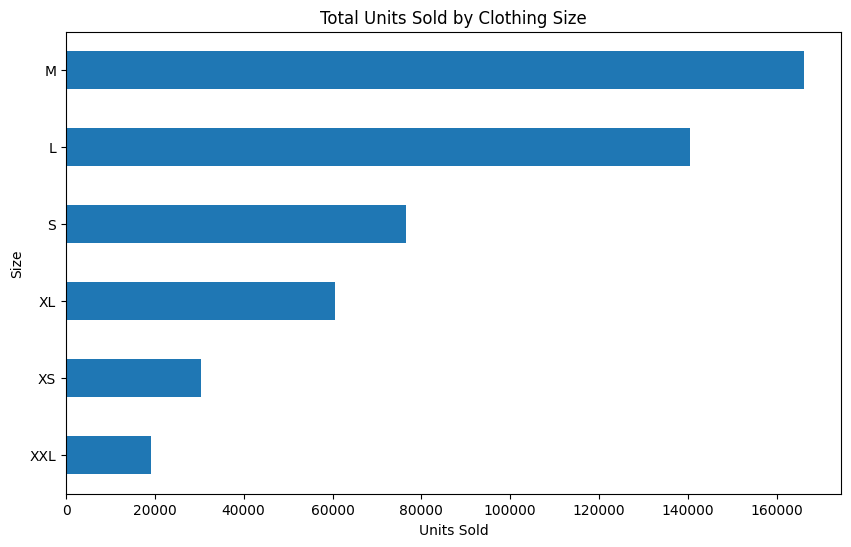

In [39]:
plt.figure(figsize=(10,6))

size_demand.sort_values().plot(kind="barh")

plt.title("Total Units Sold by Clothing Size")
plt.xlabel("Units Sold")
plt.ylabel("Size")

plt.show()

In [40]:
most_demanded_size = size_demand.idxmax()
highest_demand = size_demand.max()

print("Most demanded size:", most_demanded_size)
print("Units sold:", highest_demand)

Most demanded size: M
Units sold: 166192


In [41]:
least_demanded_size = size_demand.idxmin()

print("Least demanded size:", least_demanded_size)
print("Units sold:", size_demand.min())

Least demanded size: XXL
Units sold: 19157


In [42]:
average_size_demand = (
    df.groupby("Size")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

print(average_size_demand)

Size
M      29.836984
L      27.590650
S      22.478733
XL     20.667348
XS     18.990596
XXL    13.683571
Name: Units_Sold, dtype: float64


In [43]:
regional_size = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Region",
    columns="Size",
    aggfunc="sum",
    fill_value=0
)

regional_size

Size,L,M,S,XL,XS,XXL
Region,,,,,,
East,36788,44456,20463,15887,8086,4671
North,36589,43657,19471,16801,7850,5053
South,38828,46387,22194,16614,8343,5614
West,28259,31692,14502,11336,6011,3819


In [44]:
regional_percentage = (
    regional_size.div(regional_size.sum(axis=1), axis=0) * 100
).round(2)

regional_percentage

Size,L,M,S,XL,XS,XXL
Region,,,,,,
East,28.22,34.10,15.70,12.19,6.20,3.58
North,28.27,33.73,15.04,12.98,6.07,3.90
South,28.14,33.62,16.08,12.04,6.05,4.07
West,29.55,33.14,15.17,11.86,6.29,3.99


<Figure size 1200x600 with 0 Axes>

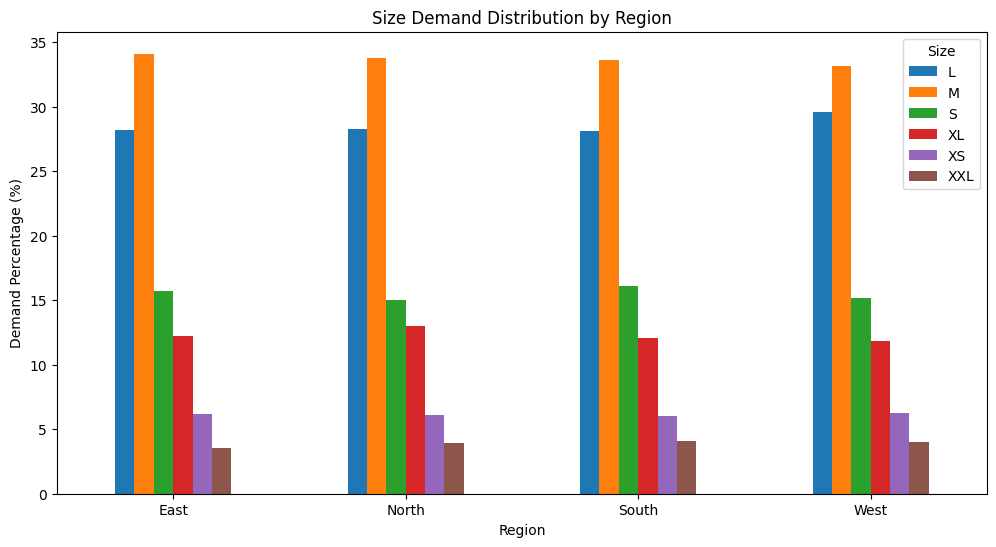

In [45]:
plt.figure(figsize=(12,6))

regional_percentage.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Size Demand Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Demand Percentage (%)")
plt.xticks(rotation=0)

plt.legend(title="Size")

plt.show()

In [46]:
regional_top_size = regional_percentage.idxmax(axis=1)

print("Most demanded size by region:")
print(regional_top_size)

Most demanded size by region:
Region
East     M
North    M
South    M
West     M
dtype: object


In [47]:
for region in regional_percentage.index:
    size = regional_percentage.loc[region].idxmax()
    percentage = regional_percentage.loc[region].max()

    print(
        f"{region}: {size} "
        f"({percentage:.2f}% of regional demand)"
    )

East: M (34.10% of regional demand)
North: M (33.73% of regional demand)
South: M (33.62% of regional demand)
West: M (33.14% of regional demand)


In [48]:
seasonal_sales = (
    df.groupby("Season")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print(seasonal_sales)

Season
Winter    132344
Summer    131334
Spring    119208
Autumn    110485
Name: Units_Sold, dtype: int64


In [49]:
seasonal_average = (
    df.groupby("Season")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

print(seasonal_average)

Season
Winter    27.020008
Summer    25.782097
Spring    23.475384
Autumn    22.415297
Name: Units_Sold, dtype: float64


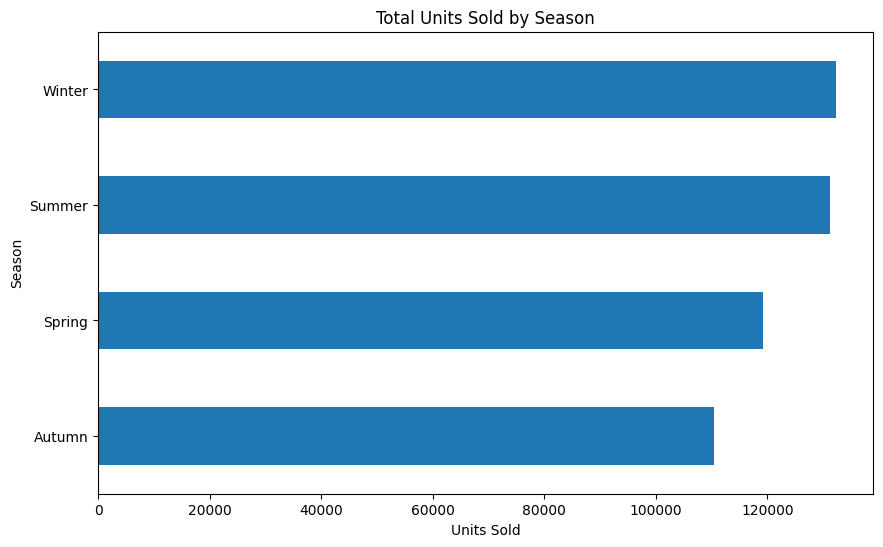

In [50]:
plt.figure(figsize=(10,6))

seasonal_sales.sort_values().plot(kind="barh")

plt.title("Total Units Sold by Season")
plt.xlabel("Units Sold")
plt.ylabel("Season")

plt.show()

In [53]:
product_sales = (
    df.groupby("Product_ID")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales.head(10))
print(product_sales.tail(10))

Product_ID
P002    23601
P012    22528
P013    21138
P003    21090
P008    20559
P026    20385
P010    19044
P021    18967
P028    18579
P029    18552
Name: Units_Sold, dtype: int64
Product_ID
P023    14005
P005    13575
P022    13137
P015    12948
P027    12923
P016    12763
P006    11936
P007    11410
P011    11285
P030    11244
Name: Units_Sold, dtype: int64


In [54]:
return_by_size = pd.crosstab(
    df["Size"],
    df["Return_Status"]
)

return_by_size

Return_Status,Not Returned,Returned,Unknown
Size,,,
L,4683,384,24
M,5184,357,29
S,3140,252,17
XL,2536,383,15
XS,1447,135,13
XXL,1200,198,2


In [55]:
returned = df[df["Return_Status"] == "Returned"]

return_rate = (
    returned.groupby("Size").size()
    / df.groupby("Size").size()
    * 100
)

print(return_rate.round(2))

Size
L       7.54
M       6.41
S       7.39
XL     13.05
XS      8.46
XXL    14.14
dtype: float64


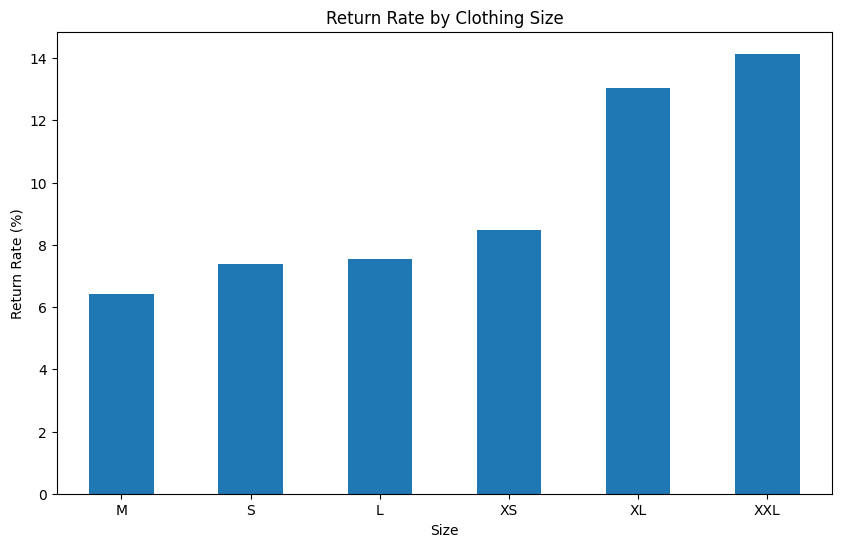

In [56]:
plt.figure(figsize=(10,6))

return_rate.sort_values().plot(kind="bar")

plt.title("Return Rate by Clothing Size")
plt.xlabel("Size")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [57]:
product_return_rate = (
    df.groupby("Product_ID")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
    .sort_values(ascending=False)
)

print(product_return_rate.head(10))

Product_ID
P027    15.123457
P019    13.333333
P007    12.345679
P012    10.835913
P017     9.883721
P001     9.710145
P015     9.375000
P008     9.355828
P025     9.214502
P024     9.119011
Name: Return_Status, dtype: float64


In [58]:
product_size_returns = (
    df.groupby(["Product_ID", "Size"])
    .agg(
        Total_Records=("Return_Status", "count"),
        Returns=("Return_Status", lambda x: (x == "Returned").sum())
    )
)

product_size_returns["Return_Rate"] = (
    product_size_returns["Returns"]
    / product_size_returns["Total_Records"]
    * 100
)

product_size_returns = product_size_returns.sort_values(
    "Return_Rate",
    ascending=False
)

product_size_returns.head(15)

Total_Records  Returns  Return_Rate
Product_ID Size                                     
P008       XXL              57       16    28.070175
P019       XXL              56       13    23.214286
P001       XXL              39        9    23.076923
P009       XXL              46       10    21.739130
P027       XL               95       20    21.052632
           XXL              53       11    20.754717
P015       XL               97       20    20.618557
P017       XXL              45        9    20.000000
P027       S               106       21    19.811321
P028       XXL              48        9    18.750000
P023       XS               54       10    18.518519
P007       XXL              50        9    18.000000
P016       XXL              45        8    17.777778
P012       XS               57       10    17.543860
P015       XXL              35        6    17.142857

In [59]:
unusual_returns = product_size_returns[
    product_size_returns["Total_Records"] >= 20
]

unusual_returns.head(15)

Total_Records  Returns  Return_Rate
Product_ID Size                                     
P008       XXL              57       16    28.070175
P019       XXL              56       13    23.214286
P001       XXL              39        9    23.076923
P009       XXL              46       10    21.739130
P027       XL               95       20    21.052632
           XXL              53       11    20.754717
P015       XL               97       20    20.618557
P017       XXL              45        9    20.000000
P027       S               106       21    19.811321
P028       XXL              48        9    18.750000
P023       XS               54       10    18.518519
P007       XXL              50        9    18.000000
P016       XXL              45        8    17.777778
P012       XS               57       10    17.543860
P015       XXL              35        6    17.142857

In [60]:
size_mix = (
    df.groupby("Size")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

ideal_size_mix = (
    size_mix / size_mix.sum() * 100
).round(2)

print("Recommended historical-demand size mix:")
print(ideal_size_mix)

Recommended historical-demand size mix:
Size
M      33.68
L      28.47
S      15.53
XL     12.29
XS      6.14
XXL     3.88
Name: Units_Sold, dtype: float64


In [61]:
inventory_target = 1000

recommended_inventory = (
    ideal_size_mix / 100 * inventory_target
).round().astype(int)

print("Recommended inventory for 1,000 units:")
print(recommended_inventory)

Recommended inventory for 1,000 units:
Size
M      337
L      285
S      155
XL     123
XS      61
XXL     39
Name: Units_Sold, dtype: int64


In [62]:
regional_mix = pd.crosstab(
    df["Region"],
    df["Size"],
    values=df["Units_Sold"],
    aggfunc="sum"
)

regional_mix_percentage = (
    regional_mix.div(regional_mix.sum(axis=1), axis=0) * 100
).round(2)

regional_mix_percentage

Size,L,M,S,XL,XS,XXL
Region,,,,,,
East,28.22,34.10,15.70,12.19,6.20,3.58
North,28.27,33.73,15.04,12.98,6.07,3.90
South,28.14,33.62,16.08,12.04,6.05,4.07
West,29.55,33.14,15.17,11.86,6.29,3.99


In [63]:
ml_df = df.copy()

In [64]:
ml_df = ml_df.drop(
    columns=["Date", "Month_Name", "Return_Status"],
    errors="ignore"
)

In [65]:
ml_df = pd.get_dummies(
    ml_df,
    columns=[
        "Product_ID",
        "Size",
        "Store_ID",
        "Season",
        "Customer_Demographics",
        "Region"
    ],
    drop_first=True
)

In [66]:
ml_df.head()

,Units_Sold,Year,Month,Product_ID_P002,Product_ID_P003,Product_ID_P004,Product_ID_P005,Product_ID_P006,Product_ID_P007,Product_ID_P008,...,Season_Summer,Season_Winter,Customer_Demographics_25-34,Customer_Demographics_35-44,Customer_Demographics_45-54,Customer_Demographics_55+,Customer_Demographics_Unknown,Region_North,Region_South,Region_West
0,30,2023,1,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,42,2023,1,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
2,28,2023,1,False,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
3,18,2023,1,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,23,2023,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [67]:
X = ml_df.drop("Units_Sold", axis=1)

y = ml_df["Units_Sold"]

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19999, 61)
y shape: (19999,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 15999
Testing records: 4000


In [70]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [71]:
y_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[24.105      30.51291667  9.445      24.9525     55.99157143 18.145
 24.         36.33333333 26.83       32.455     ]


In [72]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 4.88


In [73]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", round(rmse, 2))

Root Mean Squared Error: 6.29


In [74]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 3))

R² Score: 0.681


In [75]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
31,Size_M,0.086444
1,Month,0.059233
53,Customer_Demographics_25-34,0.055470
35,Size_XXL,0.051961
56,Customer_Demographics_55+,0.040164
39,Store_ID_S005,0.034642
12,Product_ID_P012,0.034190
2,Product_ID_P002,0.033145
38,Store_ID_S004,0.033115
48,Store_ID_S014,0.031781


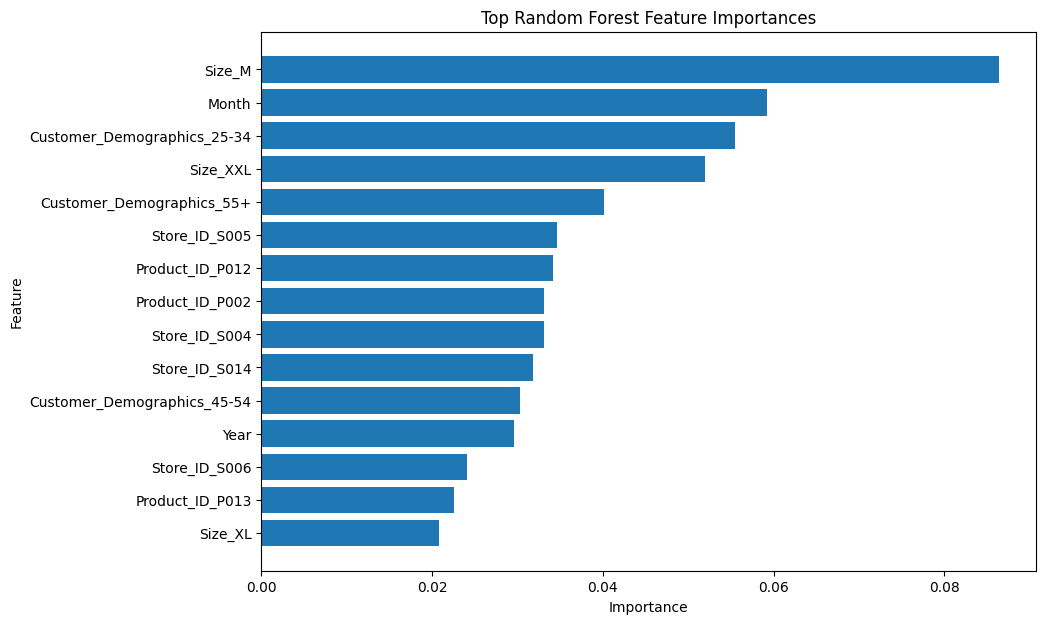

In [76]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [77]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,18,24.105000
1,30,30.512917
2,11,9.445000
3,28,24.952500
4,38,55.991571
5,14,18.145000
6,20,24.000000
7,26,36.333333
8,41,26.830000
9,29,32.455000


In [78]:
comparison["Error"] = (
    comparison["Actual"] - comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Error
0,18,24.105000,-6.105000
1,30,30.512917,-0.512917
2,11,9.445000,1.555000
3,28,24.952500,3.047500
4,38,55.991571,-17.991571
5,14,18.145000,-4.145000
6,20,24.000000,-4.000000
7,26,36.333333,-10.333333
8,41,26.830000,14.170000
9,29,32.455000,-3.455000
